In [1]:
import os
import glob
import xarray as xr
import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
import rasterio
import seaborn as sns
from shapely.geometry import box
from rasterio.enums import Resampling
import time
import gc

In [2]:
# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "eto"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [3]:
# --- 1. Fix the Automatic Band List (Ignore previous results) ---
main_folder = 'F://ETc'
required_bands = []
# Names of files we want to IGNORE as inputs
outputs_to_ignore = ['ActVP', 'Albedo', 'ETo', 'RN-MJ', 'SatVP']
i = 0
for subfolder in os.listdir(main_folder):
    sub_path = os.path.join(main_folder, subfolder)
    if not os.path.isdir(sub_path): continue
        
    for filename in os.listdir(sub_path):
        if filename.endswith(".tif"):
            img_name = filename.split('_')[0]
            # ONLY add to required_bands if it's NOT a result file
            if img_name not in outputs_to_ignore and img_name not in required_bands:
                required_bands.append(img_name)
    break # Only need to check one folder to get the list

In [4]:
required_bands

['B05',
 'B06',
 'B07',
 'B10',
 'B11',
 'B12',
 'B8A',
 'blue',
 'green',
 'ndvi',
 'red',
 'RH',
 'SRad',
 'TMax',
 'TMin',
 'Wind']

# ETo

### Calculates albedo using Vanino et al. (2018) coefficients.
##### α=(0.1324×ρB2)+(0.1269×ρB3)+(0.1051×ρB4)+(0.0971×ρB5)+(0.0890×ρB6)+(0.0818×ρB7)+(0.0722×ρB8A)+(0.0167×ρB11)+(0.0002×ρB12)
Vanino, S., Ninoa, P., De Michele, C., Bolognesi, S. F., D'Urso,  G., Di Bene, C., Pennelli, B., Vuolo, F., Farina, R., Pulighe, G., Napoli, R., 2018. Capability of Sentinel-2 data for estimating maximum evapotranspiration  and irrigation requirements for tomato crop in Central Italy. Remote Sensing of Environment. Volume 215, 15 September 2018, Pages 452-470. https://doi.org/10.1016/j.rse.2018.06.035

In [5]:
# --- 2. Calculate the Albedo factor (Instead of dividing the array of images 'ds' by 10000, we did it on the fraction for each image ) ---
def calculate_albedo(ds):
    """
    Calculates albedo using Vanino et al. (2018) coefficients.
    Input: ds (xarray.Dataset) containing bands B02, B03, etc., scaled to reflectance.
    """
    albedo = (0.00001324 * ds.blue) + \
             (0.00001269 * ds.green) + \
             (0.00001051 * ds.red) + \
             (0.00000971 * ds.B05) + \
             (0.00000890 * ds.B06) + \
             (0.00000818 * ds.B07) + \
             (0.00000722 * ds.B8A) + \
             (0.00000167 * ds.B11) + \
             (0.00000002 * ds.B12)
    
    return albedo

### Calculates surface emissivity (dimensionless, ranging from 0 to 1).
##### ϵs = ϵv . PV + ϵSU(1 - PV)
##### PV = ((NDVI - NDVImin) / (NDVImax - NDVImin))2
Valor, E.; Caselles, V. Mapping land surface emissivity from NDVI: Application to European, African, and South American areas. Remote Sens. Environ. 1996, 57, 167–184.




Meng, X.; Cheng, J.; Zhao, S.; Liu, S.; Yao, Y. Estimating Land Surface Temperature from Landsat-8 Data using the NOAA JPSS Enterprise Algorithm. Remote Sens. 2019, 11, 155.

In [6]:
# --- 3. Enhanced Emissivity (No Division by Zero) ---
def get_surface_emissivity(ds):
    """
    Calculates Surface Emissivity.
    """
    # 1. Get dynamic min/max (using 5nd/95th percentile to avoid outliers for robustness)
    # Using 0.05 and 0.95 is a standard "safe" range in literature (e.g., Sobrino et al.)
    # to ensure you are capturing the actual soil and vegetation peaks of the histogram.
    # Use quantile, but handle potential NaN/identical values
    n_min = float(ds.ndvi.quantile(0.05, skipna=True).compute())
    n_max = float(ds.ndvi.quantile(0.95, skipna=True).compute())
    
    diff = n_max - n_min
    if diff <= 0: diff = 0.01 # Prevent division by zero
    
    pv = ((ds.ndvi - n_min) / diff)**2
    pv = pv.where(ds.ndvi >= n_min, 0).where(ds.ndvi <= n_max, 1)
    
    return (0.985 * pv) + (0.960 * (1 - pv))

### Calculates atmospheric emissivity (dimensionless, ranging from 0 to 1).
##### ϵa = 0.85(-Ln(τsw))0.09
##### τsw = 0.75 _ 0.00002 . z
Bastiaanssen, W. G. M. Regionalization of Surface Flux Densities and Moisture Indicators in Composite Terrain: A Remote Sensing Approach Under Clear Skies in Mediterranean Climates (Wageningen University and Research, 1995).



Morales-Salinas, L., Ortega-Farias, S., Riveros-Burgos, C. et al. Assessment of atmospheric emissivity models for clear-sky conditions with reanalysis data. Sci Rep 13, 14465 (2023). https://doi.org/10.1038/s41598-023-40499-6.

In [7]:
def get_atmospheric_emissivity(altitude_map):
    """
    Calculates Atmospheric Emissivity.
    """
    # Atmospheric Emissivity (Bastiaanssen, 1995)
    tau_sw = 0.75 + (2e-5 * altitude_map)
    epsilon_a = 0.85 * ((-np.log(tau_sw))**0.09)
    
    return epsilon_a

### Calculates Net Radiation
##### Incoming Longwave Radiation (Rlwin): Rinlw=ϵa×σ×Ta4
##### Outgoing Longwave Radiation (Rlwout): Routlw=ϵs×σ×Ts4
##### Net Shortwave Radiation (Rswnet): Rswnet =Rs×(1−α)
##### Net Radiation (Rn): Rn=Rnetsw+Rinlw−Routlw
Monteith, J. L., & Unsworth, M. H. (2013). Principles of Environmental Physics. Academic Press. (This book provides a comprehensive overview of surface energy balance and radiation principles).


Allen, R. G., Pereira, L. S., Raes, D., & Smith, M. (1998). Crop evapotranspiration - Guidelines for computing crop water requirements - FAO Irrigation and drainage paper 56. FAO. (Chapter 3 discusses radiation).

In [8]:
def calculate_net_radiation(albedo, epsilon_s, epsilon_a, ds):
    """
    Calculates Net Radiation (Rn) in W/m2 and MJ/m2/day.
    """
    sigma = 5.670374419e-8
    
    # 1. Net Shortwave Radiation (Convert MJ to W/m2 for the balance)
    r_sw_net = (ds.SRad / 0.0864) * (1 - albedo)  # Solar radiation from weather data is in MJ/m2
    
    # 2. Incoming Longwave (Tair in Kelvin)
    t_air_k = (((ds.TMax + ds.TMin) / 2) + 273.15)
    r_lw_in = epsilon_a * sigma * (t_air_k**4)
    
    # 3. Outgoing Longwave (LST in Kelvin)
    lst_k = ds.B10
    r_lw_out = epsilon_s * sigma * (lst_k**4)
    
    # 4. Net Radiation (W/m2)
    rn_wm2 = r_sw_net + r_lw_in - r_lw_out
    
    # 5. Conversion to MJ/m2/day
    # 1 W/m2 = 0.0864 MJ/m2/day
    rn_mj = rn_wm2 * 0.0864
    
    return rn_mj

### Calculates Reference Evapotranspiration ($ET_o$).
##### This function implements the final FAO Penman-Monteith logic.
##### ETo= (0.408×Δ×Rn_MJ+γ×(900 / Tmean+273)×Wind×(es−ea)) / (Δ+γ×(1+0.34×Wind))
Allen, R. G., Pereira, L. S., Raes, D., & Smith, M. (1998). Crop evapotranspiration - Guidelines for computing crop water requirements - FAO Irrigation and drainage paper 56. FAO. (Chapter 3 discusses radiation).

In [9]:
def calculate_eto(rn_mj, ds, p_kpa=101.3):
    """
    Final FAO-56 Penman-Monteith Equation.
    """
    t_mean = (ds.TMax + ds.TMin) / 2
    
    # 1. Vapor Pressure Logic
    # Better accuracy: calculate es at t_max and t_min separately
    es_tmax = 0.6108 * np.exp((17.27 * ds.TMax) / (ds.TMax + 237.3))
    es_tmin = 0.6108 * np.exp((17.27 * ds.TMin) / (ds.TMin + 237.3))
    es = (es_tmax + es_tmin) / 2
    
    ea = es * (ds.RH / 100)
    
    # 2. Slope & Psychrometric Constant
    delta = (4098 * es) / ((t_mean + 237.3)**2)
    gamma = 0.000665 * p_kpa
    
    # 3. FAO Penman-Monteith
    # Numerator parts
    term1 = 0.408 * delta * rn_mj
    term2 = gamma * (900 / (t_mean + 273)) * ds.Wind * (es - ea)
    
    # Denominator parts
    denom = delta + gamma * (1 + 0.34 * ds.Wind)
    
    eto = (term1 + term2) / denom
    
    return es, ea, eto

### Load geoimages per date
#### Create a Helper to Find the "Correct" File
##### Since your filenames have different suffixes (_mas, _rep_mas), we need a flexible way to find them.

In [10]:
def find_band_file(subfolder_path, band_name):
    """Search for a specific band file regardless of suffixes."""
    for f in os.listdir(subfolder_path):
        # Checks if file starts with band (e.g., B02) and is a .tif
        if f.startswith(band_name) and f.endswith(".tif"):
            return os.path.join(subfolder_path, f)
    return None

In [11]:
# Fetch the altitude map
altitude = rioxarray.open_rasterio('images/eto/East_delta_elevation_rep_176038_176039.tif').squeeze().astype('float32')

### The Main Processing Loop
##### It loops through dates, loads the bands into a single object, and runs the previous functions.

In [12]:
master_band_name = 'red'

In [14]:
for date_folder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, date_folder)
    if not os.path.isdir(subfolder_path): continue

    # --- NEW CHECK: SKIP IF ALREADY DONE ---
    final_output_check = os.path.join(subfolder_path, f"ETo_{date_folder}.tif")
    if os.path.exists(final_output_check):
        print(f"⏩ Skipping {date_folder}: Output already exists.")
        continue
    
    print(f"🚀 Processing: {date_folder}")

    # 1. Load the Master Band (The 10m grid, everything should follow)
    master_path = find_band_file(subfolder_path, master_band_name)
    if not master_path: continue
    # masked=True turns 0 into NaN immediately. This stops the "Millions" error.
    master_grid = rioxarray.open_rasterio(master_path, masked=True).squeeze().astype('float32')
    # Clean the master grid to ensure it acts as a valid mask
    master_grid = master_grid.where(master_grid > 0)

    # 2. Load all required bands into a dictionary
    band_data_dict = {}
    for band in required_bands:
        file_path = find_band_file(subfolder_path, band)
        if file_path:
            # Masked=True is key to preventing the "Millions" error from NoData
            da = rioxarray.open_rasterio(file_path, masked=True).squeeze().astype('float32')
            # resampling=1 (Bilinear) is essential for smooth weather data (9.8m -> 10m)
            band_data_dict[band] = da.rio.reproject_match(master_grid, resampling=1)
        else:
            print(f"Warning: Missing {band} for {date_folder}")

    # 3. Combine the dictionary into a single xarray Dataset
    if len(band_data_dict) == len(required_bands):
        ds = xr.Dataset(band_data_dict).astype('float32')

        # Align altitude to the current date's resolution and extent
        alt_matched = altitude.rio.reproject_match(master_grid).astype('float32')
        
        # 3. Apply the functions
        albedo_map = calculate_albedo(ds)
        epsilon_s_map = get_surface_emissivity(ds)
        epsilon_a_map = get_atmospheric_emissivity(alt_matched)
        rn_mj_map = calculate_net_radiation(albedo_map, epsilon_s_map, epsilon_a_map, ds)
        es_map, ea_map, eto_map = calculate_eto(rn_mj_map, ds)

        # --- SAFETY CLAMP ---
        # Any ETo value outside 0-15mm is likely an error from bad input pixels
        eto_map = eto_map.where((eto_map > 0) & (eto_map < 15))
        rn_mj_map = rn_mj_map.where((rn_mj_map > -5) & (rn_mj_map < 45))

        # Put the results in a dictionary
        results = {
            "Albedo": albedo_map,
            "RN-MJ": rn_mj_map,
            "SatVP": es_map,
            "ActVP": ea_map,
            "ETo": eto_map
        }
        
        # 5. "Match" the metadata to be safe (copies CRS and Transform from the original dataset) and saving the results
        for name, data in results.items():
            data = data.rio.write_crs(ds.rio.crs)
            out_path = os.path.join(subfolder_path, f"{name}_{date_folder}.tif")
            data.rio.to_raster(out_path, driver="GTiff", dtype="float32", compress="lzw", tiled=True)
            print(f"Successfully saved: {out_path}")

        # Clear specific large objects from memory
        results.clear()
        del ds, albedo_map, rn_mj_map, es_map, ea_map, eto_map, alt_matched, results
        # Force Python to release the RAM back to the OS
        gc.collect()
    else:
        print(f"Skipping {date_folder} due to missing bands.")
    
    # 1. Clear the dictionary contents first
    band_data_dict.clear() 
    # 2. Delete the dictionary and the master grid
    del band_data_dict, master_grid
    # 3. Final call to the garbage collector
    gc.collect()

⏩ Skipping 2023-07-14: Output already exists.
🚀 Processing: 2023-07-22
Successfully saved: F://ETc\2023-07-22\Albedo_2023-07-22.tif
Successfully saved: F://ETc\2023-07-22\RN-MJ_2023-07-22.tif
Successfully saved: F://ETc\2023-07-22\SatVP_2023-07-22.tif
Successfully saved: F://ETc\2023-07-22\ActVP_2023-07-22.tif
Successfully saved: F://ETc\2023-07-22\ETo_2023-07-22.tif
⏩ Skipping 2023-08-07: Output already exists.
🚀 Processing: 2023-08-31
Successfully saved: F://ETc\2023-08-31\Albedo_2023-08-31.tif
Successfully saved: F://ETc\2023-08-31\RN-MJ_2023-08-31.tif
Successfully saved: F://ETc\2023-08-31\SatVP_2023-08-31.tif
Successfully saved: F://ETc\2023-08-31\ActVP_2023-08-31.tif
Successfully saved: F://ETc\2023-08-31\ETo_2023-08-31.tif
🚀 Processing: 2023-09-08
Successfully saved: F://ETc\2023-09-08\Albedo_2023-09-08.tif
Successfully saved: F://ETc\2023-09-08\RN-MJ_2023-09-08.tif
Successfully saved: F://ETc\2023-09-08\SatVP_2023-09-08.tif
Successfully saved: F://ETc\2023-09-08\ActVP_2023-09-0

 ##### Calculate the average values for the whole AoI per date.

In [4]:
stats_list = []

for date_folder in os.listdir(main_folder):
    sub_path = os.path.join(main_folder, date_folder)
    if not os.path.isdir(sub_path):
        continue

    # Define paths for both results
    eto_path = os.path.join(sub_path, f"ETo_{date_folder}.tif")
    rn_path = os.path.join(sub_path, f"RN-MJ_{date_folder}.tif")
    
    # We only process if BOTH files exist
    if os.path.exists(eto_path) and os.path.exists(rn_path):
        try:
            # Open lazily (chunks=True prevents memory spikes)
            eto_da = rioxarray.open_rasterio(eto_path, chunks=True).squeeze()
            rn_da = rioxarray.open_rasterio(rn_path, chunks=True).squeeze()
            
            # Calculate means
            # skipna=True is vital in case your AoI has jagged edges or clouds
            m_eto = float(eto_da.mean(skipna=True).compute())
            m_rn = float(rn_da.mean(skipna=True).compute())
            
            stats_list.append({
                "Date": date_folder, 
                "Mean_ETo_mm": round(m_eto, 3), 
                "Mean_Rn_MJ": round(m_rn, 3)
            })
            
            print(f"✅ {date_folder}: ETo={m_eto:.2f}, Rn={m_rn:.2f}")
            
        except Exception as e:
            print(f"❌ Error reading {date_folder}: {e}")
        finally:
            # Clear memory handle
            del eto_da, rn_da
            gc.collect()

✅ 2023-07-14: ETo=7.74, Rn=14.49
✅ 2023-07-22: ETo=7.12, Rn=14.35
✅ 2023-08-07: ETo=6.83, Rn=13.10
✅ 2023-08-31: ETo=5.60, Rn=10.72
✅ 2023-09-08: ETo=7.60, Rn=10.71
✅ 2024-06-14: ETo=6.43, Rn=10.55
✅ 2024-06-22: ETo=7.68, Rn=12.43
✅ 2024-07-08: ETo=6.88, Rn=12.68
✅ 2024-07-24: ETo=7.01, Rn=13.48
✅ 2024-08-01: ETo=6.52, Rn=12.53
✅ 2024-08-17: ETo=6.72, Rn=11.94
✅ 2024-09-02: ETo=4.77, Rn=7.05


### Creating a Comparison Table

In [5]:
# Create the DataFrame
df = pd.DataFrame(stats_list)
# CONVERT TO DATETIME (Crucial for a clean timeline)
df['Date'] = pd.to_datetime(df['Date'])
# Sort by date to make sure the plot follows the timeline
df = df.sort_values('Date')
# Convert back to string format for the X-axis to remove the "winter gap"
date_labels = df['Date'].dt.strftime('%Y-%m-%d').tolist()
# Save to CSV so you can use it in Excel for your paper
df.to_csv('Eto_Temporal_Comparison.csv', index=False)

print(df)

         Date  Mean_ETo_mm  Mean_Rn_MJ
0  2023-07-14        7.738      14.491
1  2023-07-22        7.124      14.346
2  2023-08-07        6.830      13.096
3  2023-08-31        5.602      10.721
4  2023-09-08        7.605      10.708
5  2024-06-14        6.427      10.550
6  2024-06-22        7.684      12.426
7  2024-07-08        6.883      12.679
8  2024-07-24        7.006      13.485
9  2024-08-01        6.517      12.532
10 2024-08-17        6.717      11.937
11 2024-09-02        4.774       7.046


In [3]:
# Load the saved data
df = pd.read_csv('Eto_Temporal_Comparison.csv')
df

,Date,Mean_ETo_mm,Mean_Rn_MJ
0,2023-07-14,7.738,14.491
1,2023-07-22,7.124,14.346
2,2023-08-07,6.830,13.096
3,2023-08-31,5.602,10.721
4,2023-09-08,7.605,10.708
5,2024-06-14,6.427,10.550
6,2024-06-22,7.684,12.426
7,2024-07-08,6.883,12.679
8,2024-07-24,7.006,13.485
9,2024-08-01,6.517,12.532


### Visualizing Trends (The Comparison)

Saving figure ETo_time_series


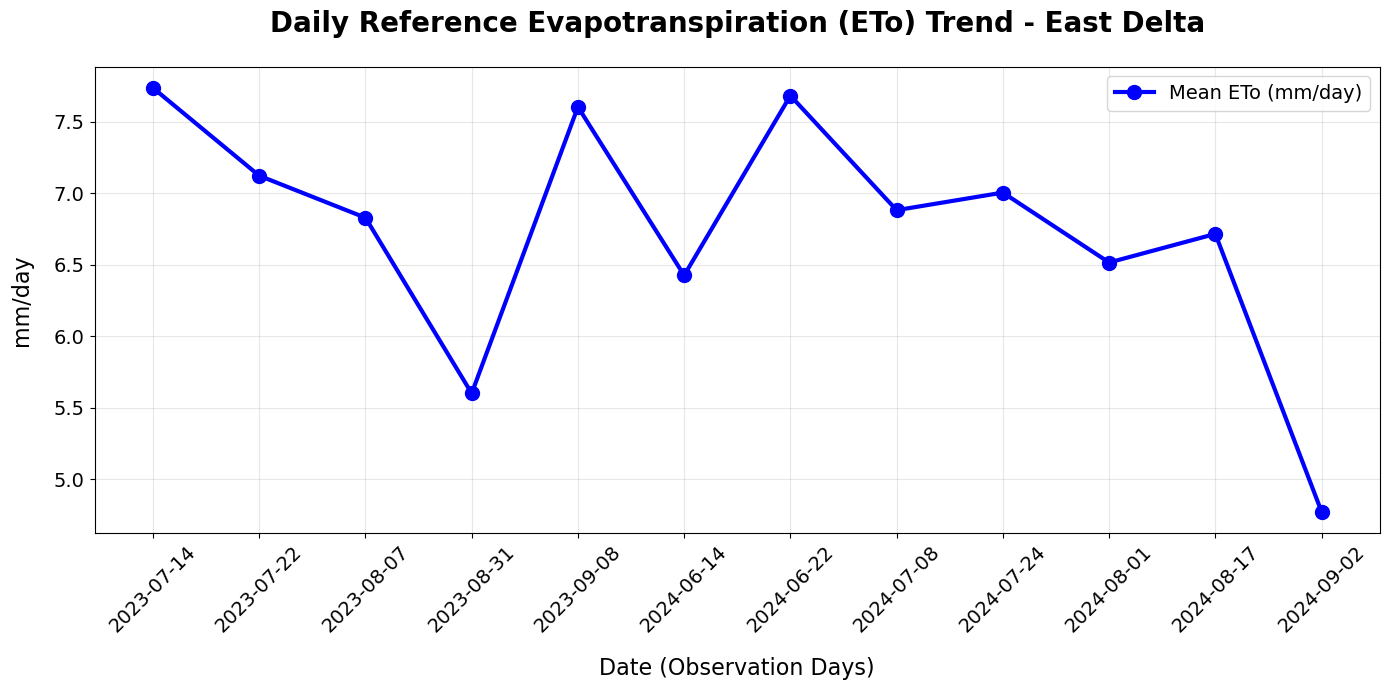

In [6]:
# A time-series line plot for ETo
plt.figure(figsize=(14, 7))
plt.plot(date_labels, df['Mean_ETo_mm'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETo (mm/day)')
plt.title('Daily Reference Evapotranspiration (ETo) Trend - East Delta', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=16, labelpad=15)
plt.ylabel('mm/day', fontsize=16, labelpad=15)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x', labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.xticks(rotation=45)
save_fig("ETo_time_series")
plt.show()

Saving figure Rn_time_series


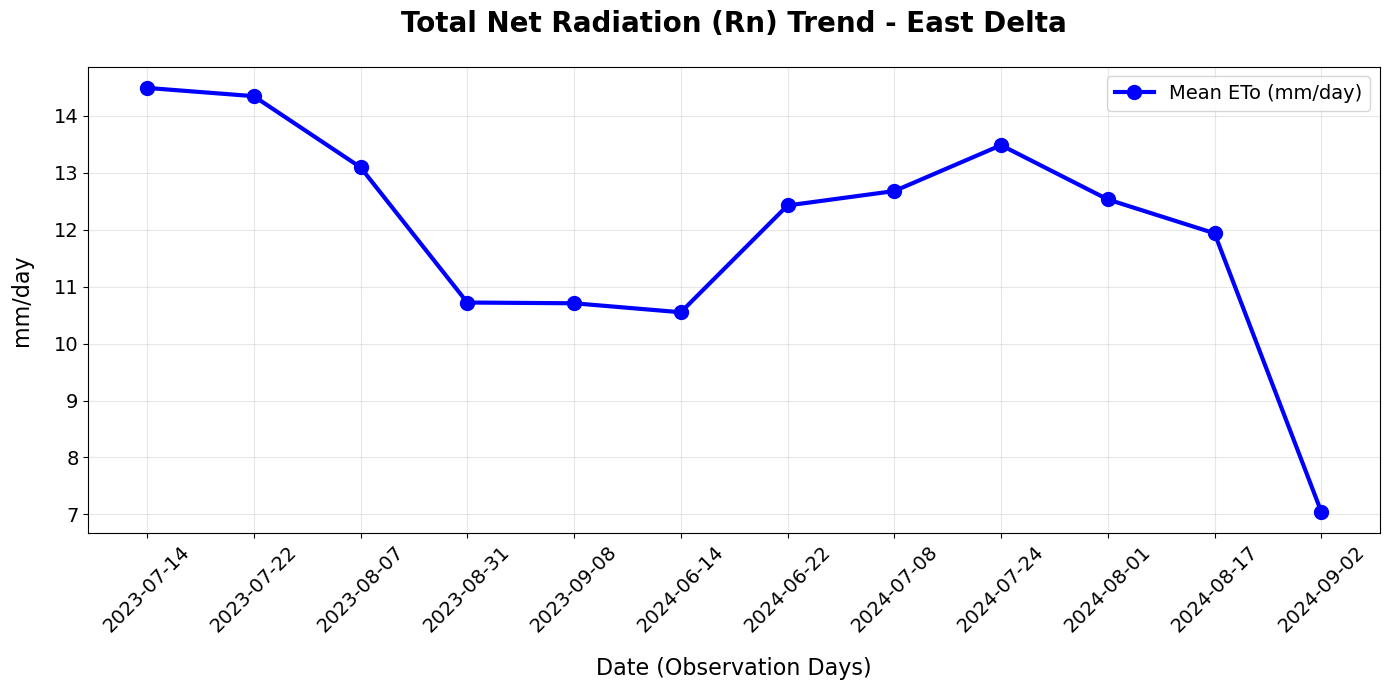

In [7]:
# A time-series line plot for Rn
plt.figure(figsize=(14, 7))
plt.plot(date_labels, df['Mean_Rn_MJ'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETo (mm/day)')
plt.title('Total Net Radiation (Rn) Trend - East Delta', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=16, labelpad=15)
plt.ylabel('mm/day', fontsize=16, labelpad=15)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x', labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.xticks(rotation=45)
save_fig("Rn_time_series")
plt.show()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_60508\846349135.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(date_labels, rotation=45, ha='right', fontsize=TICK_LABEL_SIZE)


Saving figure ETo_Rn_Comparison


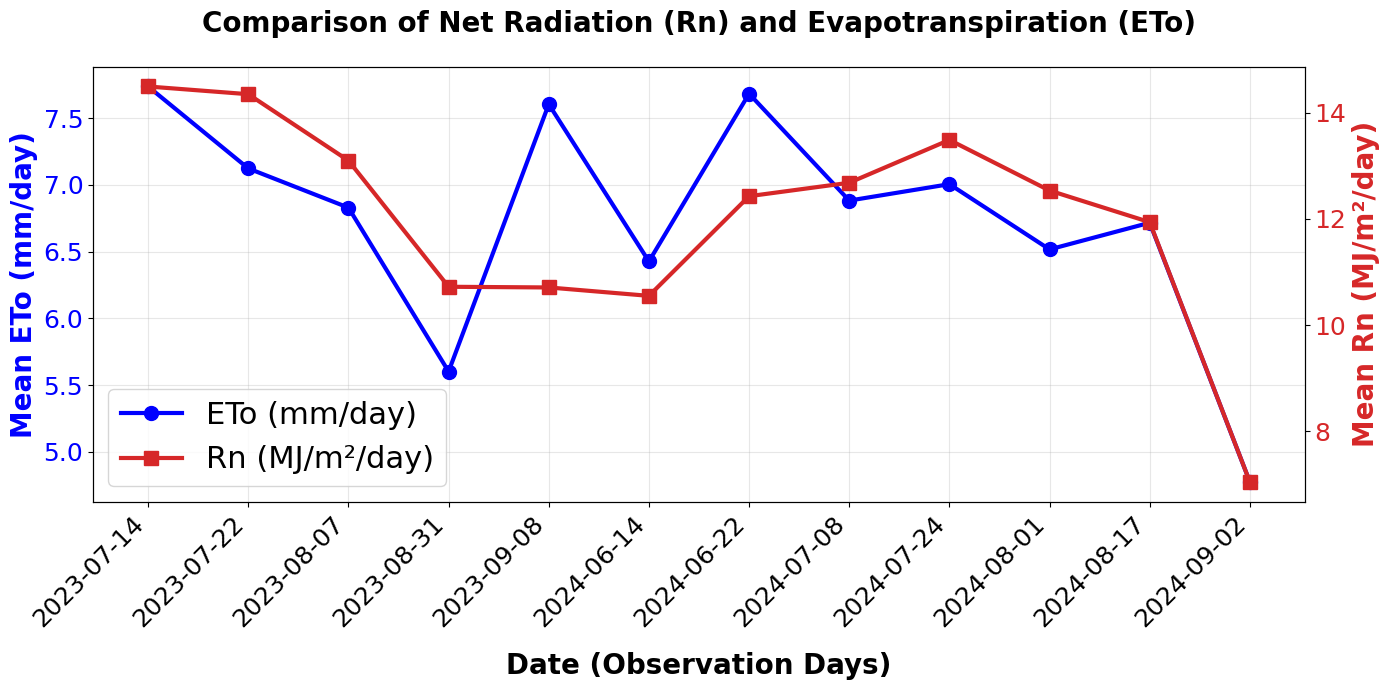

In [17]:
# 1. Prepare data (Categorical X-axis to avoid the winter gap)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
date_labels = df['Date'].dt.strftime('%Y-%m-%d').tolist()

# --- FONT SIZE SETTINGS ---
TITLE_SIZE = 20
AXIS_LABEL_SIZE = 20
TICK_LABEL_SIZE = 18
LEGEND_SIZE = 22

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Plot ETo on the First Y-Axis (Left) ---
color1 = 'blue'
ax1.set_xlabel('Date (Observation Days)', fontsize=AXIS_LABEL_SIZE, labelpad=15, fontweight='bold')
ax1.set_ylabel('Mean ETo (mm/day)', color=color1, fontsize=AXIS_LABEL_SIZE, fontweight='bold')

line1 = ax1.plot(date_labels, df['Mean_ETo_mm'], marker='o', markersize=10, 
                 linestyle='-', linewidth=3, color=color1, label='ETo (mm/day)')

# Set size for the numbers on the axis
ax1.tick_params(axis='y', labelcolor=color1, labelsize=TICK_LABEL_SIZE)
ax1.tick_params(axis='x', labelsize=TICK_LABEL_SIZE)
ax1.grid(True, alpha=0.3)

# --- Create the Second Y-Axis (Right) for Rn ---
ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Mean Rn (MJ/m²/day)', color=color2, fontsize=AXIS_LABEL_SIZE, fontweight='bold')

line2 = ax2.plot(date_labels, df['Mean_Rn_MJ'], marker='s', markersize=10, 
                 linestyle='-', linewidth=3, color=color2, label='Rn (MJ/m²/day)')

# Set size for the numbers on the right axis
ax2.tick_params(axis='y', labelcolor=color2, labelsize=TICK_LABEL_SIZE)

# --- Final Styling & Font Adjustments ---
plt.title('Comparison of Net Radiation (Rn) and Evapotranspiration (ETo)', 
          fontsize=TITLE_SIZE, fontweight='bold', pad=25)

# Rotate and size X-axis date labels
ax1.set_xticklabels(date_labels, rotation=45, ha='right', fontsize=TICK_LABEL_SIZE)

# Combine legends and set font size
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left', frameon=True, fontsize=LEGEND_SIZE)

fig.tight_layout()
# To save a high-resolution version for your paper:
save_fig("ETo_Rn_Comparison")

plt.show()